# Visualizing Immune Cell UOT using PCA/UMAP
Visaulizing UOT results for the cell line data using PCA/UMAP proved to not show much in terms of results. However, the immmune cell data showed clearer trends in the clustermap, suggesting this data will show clearer trends. Thus, we'll apply the same strategy to the UOT data for this dataset.

## Imports

In [1]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [10]:
### Directories and Files ###
root = '../../../../../'
metadata_dir = root+'Generated Data/Single-to-single/sc_uot_clustering/OT/Metadata/1mb_95_maxnorm_total_mass_celltypes.csv'
save_dir = root+'Generated Data/Single-to-single/sc_uot_clustering/OT/RandomSubsets'

In [5]:
### Imports ###
import sys
import numpy as np
import pandas as pd
from umap import UMAP
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
### Pre-importing metadata ###
metadata_df = pd.read_csv(metadata_dir, index_col=0)
metadata_df

,cell_name,cell_type,total_mass
0,arc_pair_7,T cells,24.035465
1,arc_pair_18,CD4+ T cells,13.497184
2,arc_pair_31,CD4+ T cells,16.177841
3,arc_pair_56,T cells,11.600458
4,arc_pair_57,CD8+ T cells,14.965568
...,...,...,...
8058,arc_pair_736107,T cells,13.664406
8059,arc_pair_736132,CD8+ T cells,7.776261
8060,arc_pair_736144,CD8+ T cells,7.787857
8061,arc_pair_736230,Monocytes,17.368914


## Helper Functions

### Data Handling

In [49]:
def load_ot_data_numpy(
        folder: str, 
        res: int, 
        thres: int, 
        reg_m: float,
        count: int=20,
        seed: int=42
        ) -> tuple[np.ndarray, list[str]]:
    
    '''
        Loads OT results for immune cell data as an ndarray
        of OT results and a list of cell types.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        reg_m : float
            Unbalanced parameter used.
        count : int
            Number of cells per cell type used for analysis.
            Default = 20.
        seed : int
            Seed used to select data.
            Default = 42.

        Returns
        -------
        ot_ndarray : np.ndarray
            OT results in ndarray form.
        cell_types : list[str]
            List of cell types in the same order as original
            data.
    '''
    # File
    file = f"{folder}/unbalanced_reg_m={reg_m}_cluster_{res}mb_{thres}_{count}_seed={seed}.csv"

    # Importing file
    ot_df_matrix = pd.read_csv(file, index_col=0)

    # Converting to ndarray
    ot_ndarray = ot_df_matrix.to_numpy()

    # Fetching cell types   
    cell_types = []
    lymphoids = ['B cells', 'CD8+ T cells', 'CD4+ T cells', 'T cells', 'NK cells']
    myeloids = ['Dendritic cells', 'Monocytes', 'Neutrophils', 'Progenitors']
    for cell in ot_df_matrix.index:
        specific_type = metadata_df[metadata_df['cell_name'] == cell]['cell_type'].values[0]
        
        if specific_type in lymphoids:
            cell_types.append("Lymphoid")
        elif specific_type in myeloids:
            cell_types.append("Myeloid")
        else:
            raise ValueError(f"Cell type not recognized: {specific_type}")

    return ot_ndarray, cell_types

### Data Visualizing

In [50]:
def generate_clustering(
        data : np.ndarray,
        cell_lines : list[str],
        seed : int,
        ax,
        kind : str = "PCA"
        ):
    '''
        Draws clustering of the data to the provided Axes object
        using either PCA of UMAP

        Parameters
        ----------
        data : np.ndarray
            OT data in ndarray form.
        cell_lines : list[str]
            List of cell lines corresponding to the cell order in
            the data.
        reg_m : int
            Used seed, for subtitle.
        ax
            Axes object to parse figure to
        kind : str
            Kind of clustering to use (PCA or UMAP).
            Default = "PCA"
    '''
    # PCA or UMAP
    if kind == "PCA":
        vec = PCA(n_components=2).fit_transform(data)
        xlab = "PC 1"
        ylab= "PC 2"
    elif kind == "UMAP":
        vec = UMAP(n_components=2).fit_transform(data)
        xlab = "UMAP 1"
        ylab= "UMAP 2"
    else:
        raise ValueError(f"Unknown clustering kind: {kind}")

    # Figure
    sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_lines, ax=ax, s=15, linewidth=0)
    handles, labels = ax.get_legend_handles_labels()
    labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
    ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=1)
    ax.set_title(f"seed={seed}")
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    return

## Loading data

In [51]:
### Data per seed ###
seeds = [42, 15, 338, 872, 674]
data_numpy = []
cell_subsets = []

for seed in seeds:
    data, cells = load_ot_data_numpy(save_dir, 1, 95, 0.1, 20, seed)
    data_numpy.append(data)
    cell_subsets.append(cells)

## PCA

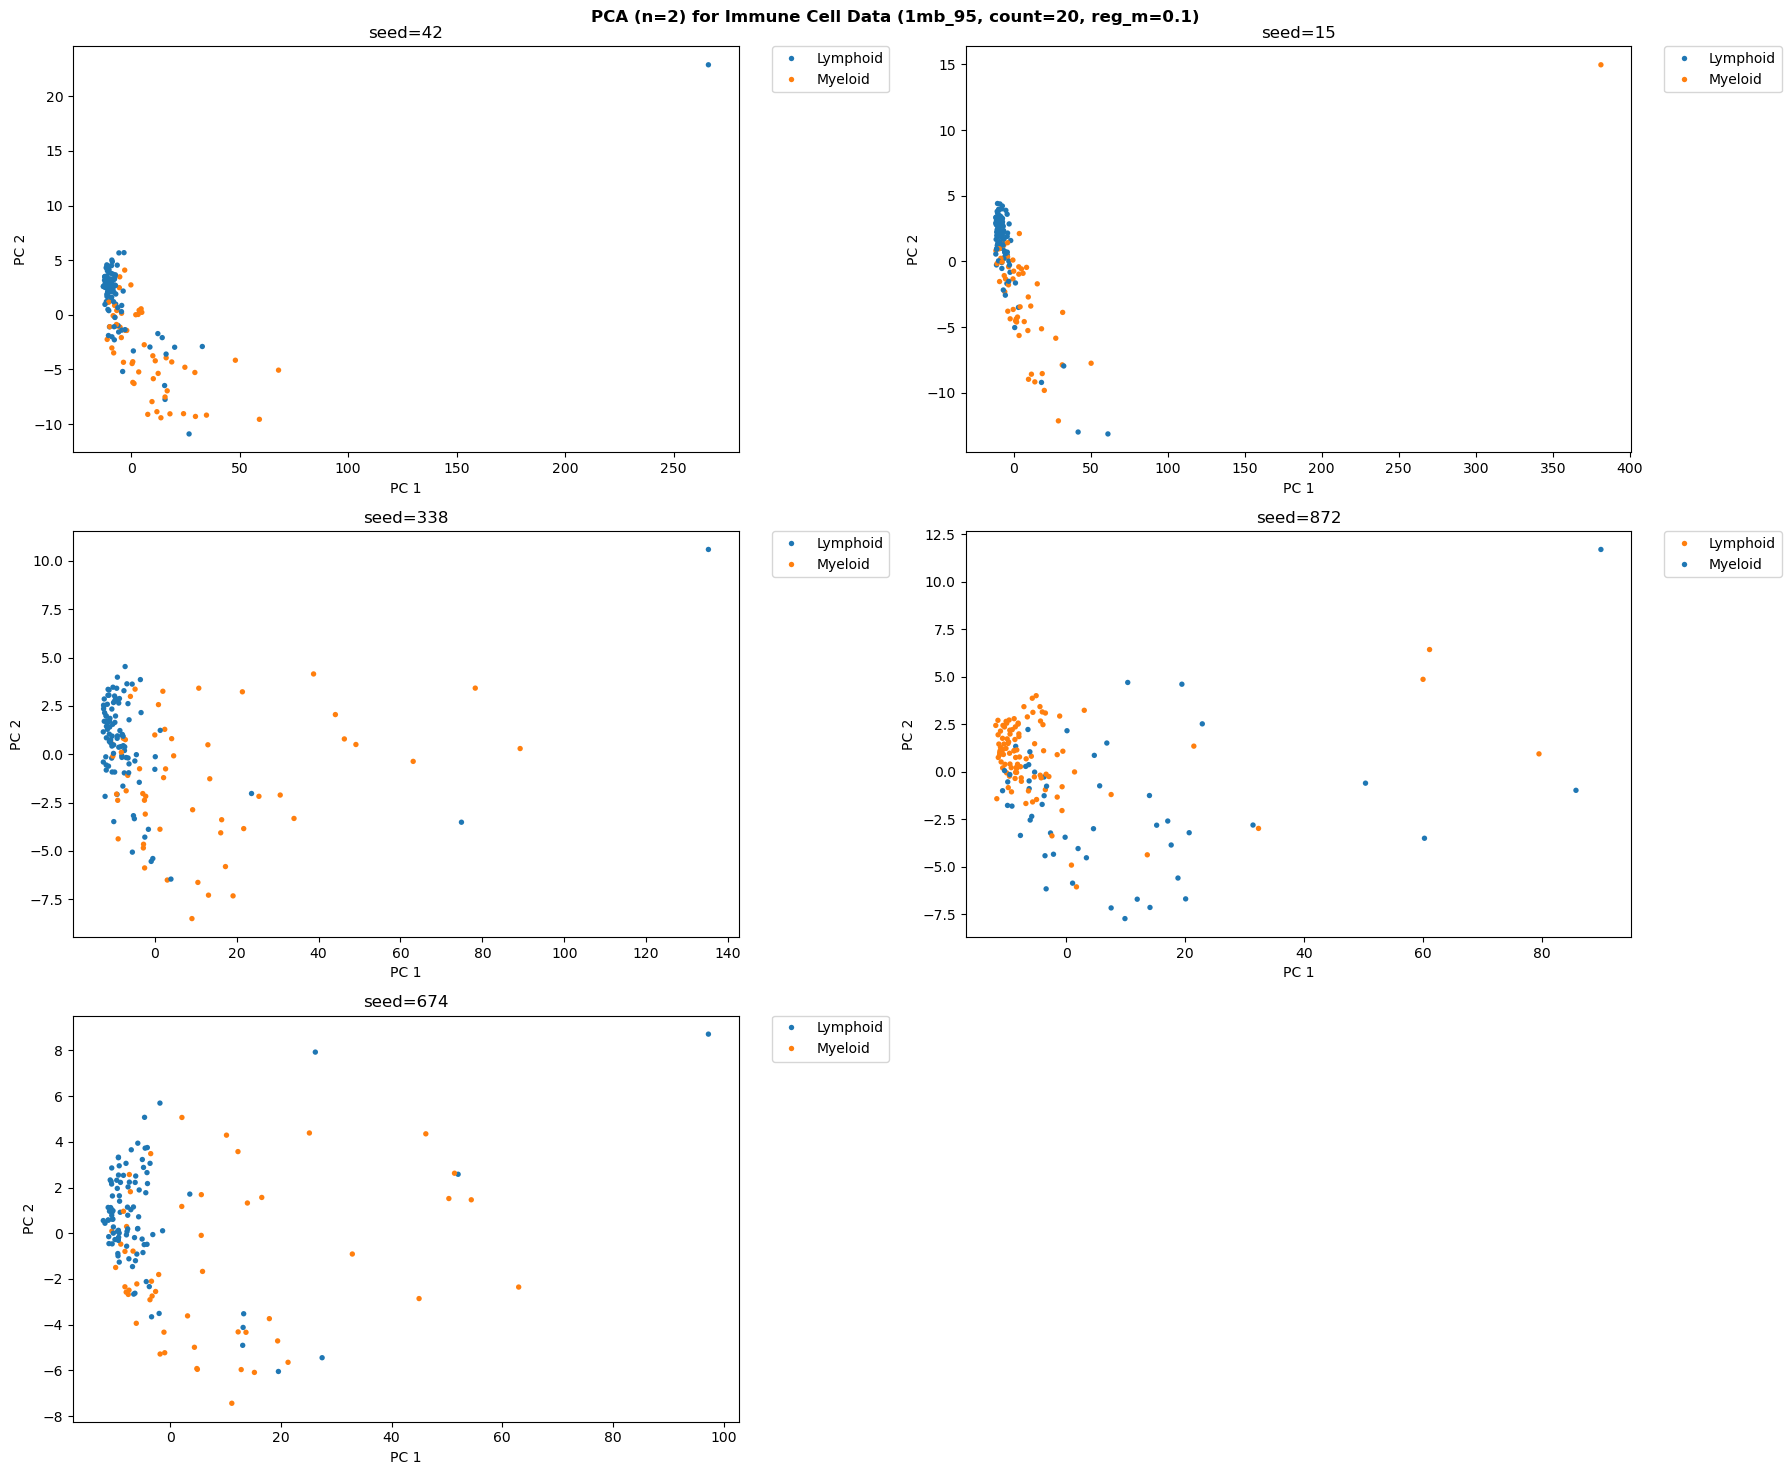

In [52]:
fig, ax = plt.subplots(3, 2, figsize=(18,15))
axes = ax.flatten()

    # Adding subpanels
for i, (seed, data, cell_subset) in enumerate(zip(seeds, data_numpy, cell_subsets)):
    generate_clustering(data, cell_subset, seed, axes[i], "PCA")

    # Adding titles
plt.suptitle("PCA (n=2) for Immune Cell Data (1mb_95, count=20, reg_m=0.1)", fontweight="bold")
fig.delaxes(ax[2, 1])
plt.tight_layout()

## UMAP

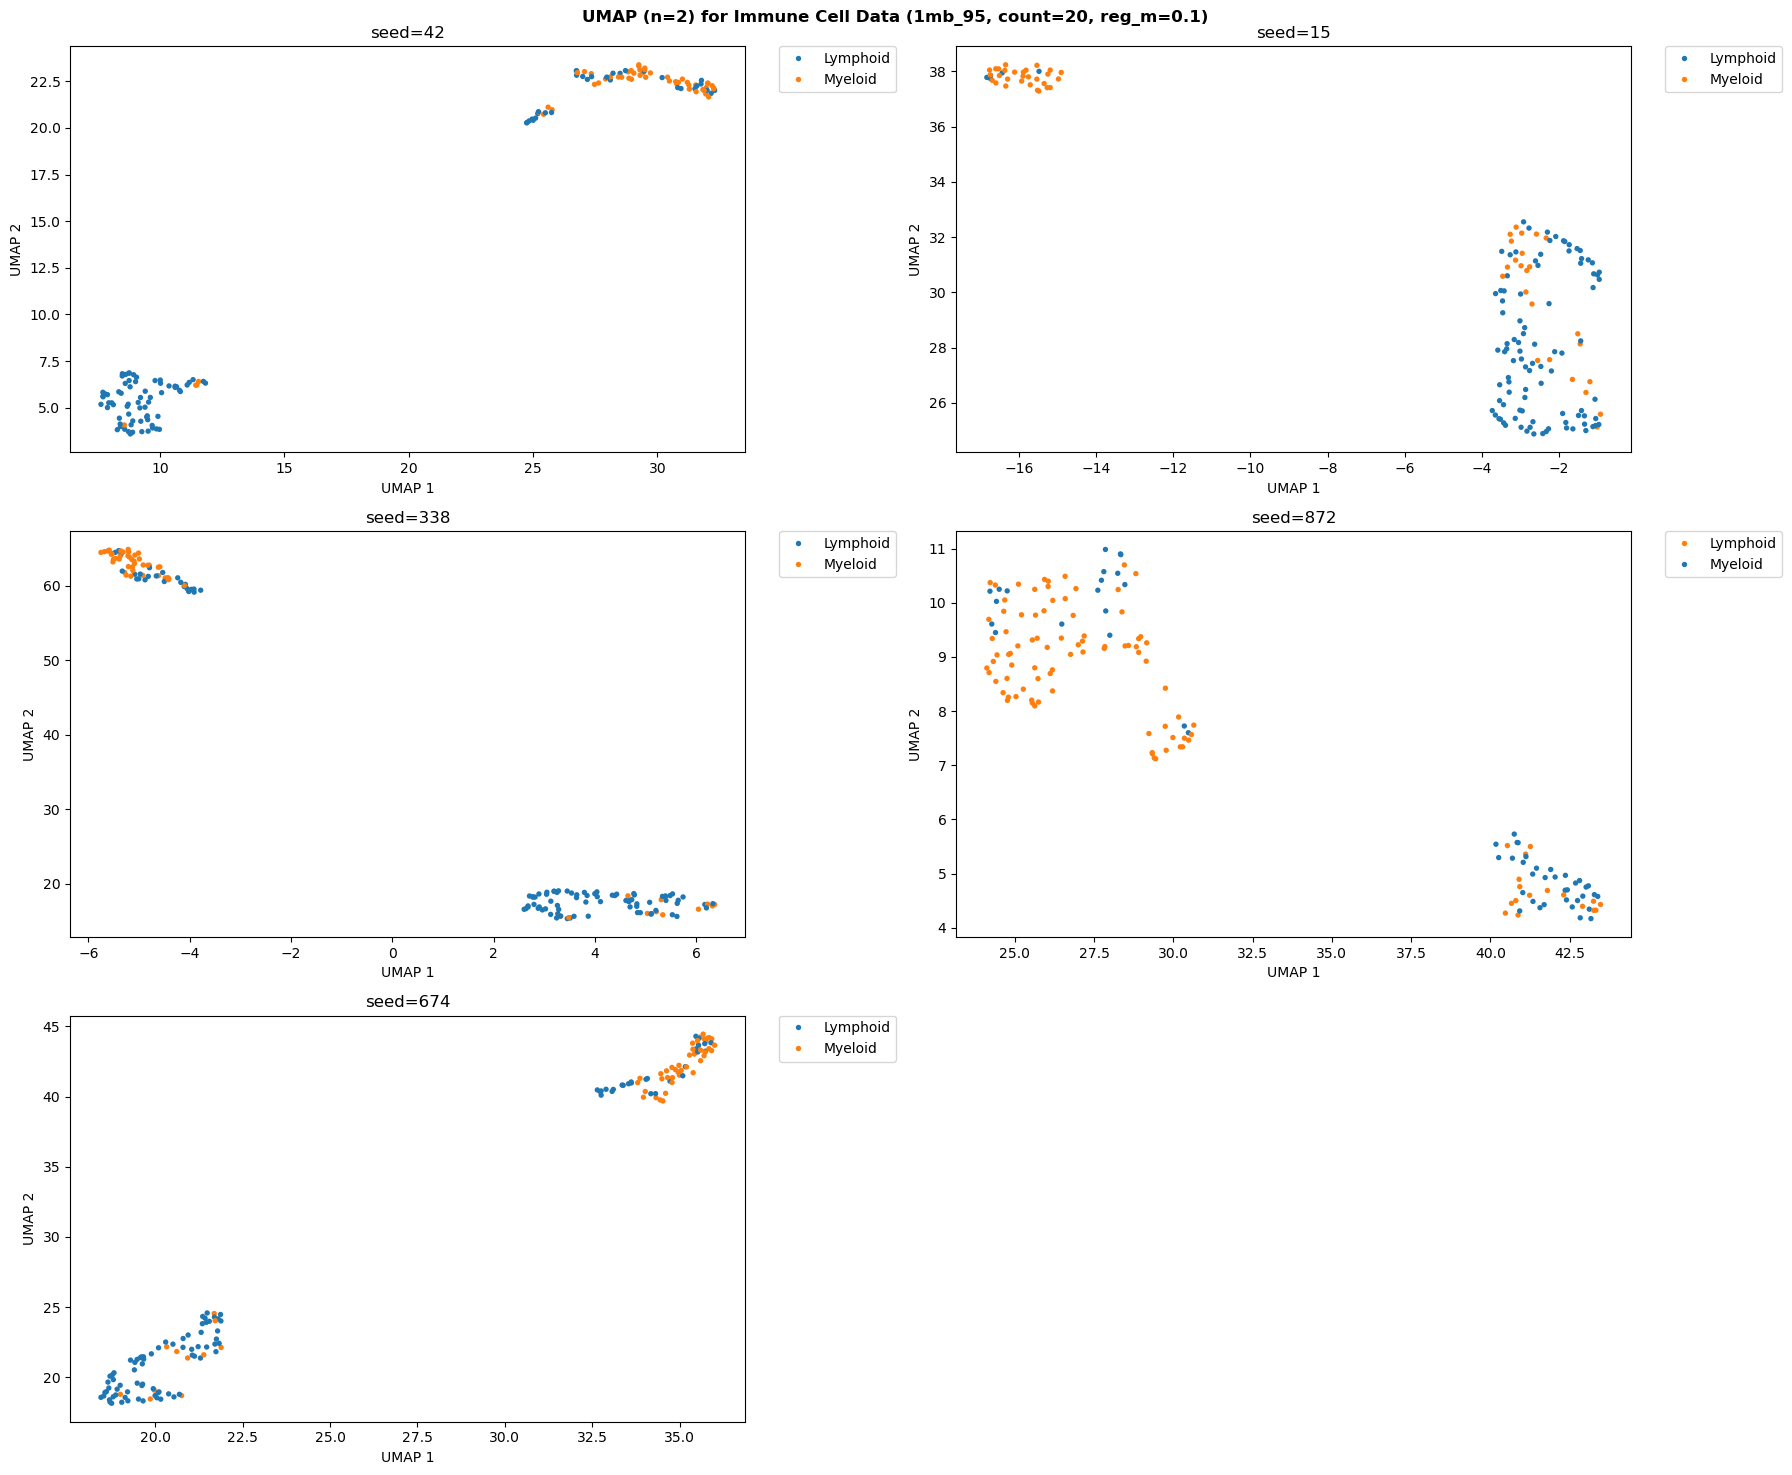

In [55]:
fig, ax = plt.subplots(3, 2, figsize=(18,15))
axes = ax.flatten()

    # Adding subpanels
for i, (seed, data, cell_subset) in enumerate(zip(seeds, data_numpy, cell_subsets)):
    generate_clustering(data, cell_subset, seed, axes[i], "UMAP")

    # Adding titles
plt.suptitle("UMAP (n=2) for Immune Cell Data (1mb_95, count=20, reg_m=0.1)", fontweight="bold")
fig.delaxes(ax[2, 1])
plt.tight_layout()

Here, especially when considering the UMAPs, there does indeed seem to be nice clustering of results.